# Letterboxd Ratings Enricher

This notebook takes a raw Letterboxd ratings export (`ratings.csv`)  
and appends three columns scraped from each film's Letterboxd page:

| Column | Description |
|--------|-------------|
| `Genres` | Pipe of genres joined with `-` (e.g. `Drama-Music-Thriller`) |
| `Runtime` | Film length in minutes (float) |
| `Average Rating` | Letterboxd community weighted average (float) |

### Requirements
```
pip install requests beautifulsoup4 lxml tqdm
```

### How to run
1. Place `ratings.csv` (raw Letterboxd export) next to this notebook.  
2. Run all cells in order.  
3. A checkpoint file (`enrichment_checkpoint.csv`) is written after **every row**  
   so you can safely interrupt and resume — the notebook skips rows that are  
   already present in the checkpoint.  
4. The final enriched file is saved as `ratings_enriched.csv`.


In [ ]:
import time
import random
import json
import re
import os
import pandas as pd
import requests
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm

# ── Configuration ──────────────────────────────────────────────────────────────
INPUT_CSV        = "../data/ratings.csv"          # Raw Letterboxd export (5 columns)
CHECKPOINT_CSV   = "../data/ratings_enrichment_checkpoint.csv"
OUTPUT_CSV       = "../data/ratings_enriched.csv"

DELAY_MIN        = 1.2   # seconds between requests (be polite!)
DELAY_MAX        = 2.8
REQUEST_TIMEOUT  = 20    # seconds

# Realistic browser headers — Letterboxd requires a real User-Agent
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.5",
    "Connection": "keep-alive",
}

print("✅ Imports OK")


✅ Imports OK


In [17]:
# Load the raw export — keep only the 5 base columns so the notebook is
# idempotent even if you accidentally run it on an already-enriched file.
BASE_COLS = ["Date", "Name", "Year", "Letterboxd URI", "Rating"]

df_base = pd.read_csv(INPUT_CSV, usecols=lambda c: c in BASE_COLS)

# Validate expected columns are present
missing = set(BASE_COLS) - set(df_base.columns)
assert not missing, f"Missing columns in input CSV: {missing}"

print(f"Loaded {len(df_base):,} rows from '{INPUT_CSV}'")
df_base.head(3)


Loaded 1,005 rows from '../images/ratings.csv'


,Date,Name,Year,Letterboxd URI,Rating
0,2020-10-15,Whiplash,2014,https://boxd.it/7bQA,5.0
1,2020-10-15,Your Name.,2016,https://boxd.it/cUqs,5.0
2,2020-10-15,Super Deluxe,2019,https://boxd.it/fjRW,5.0


In [18]:
# The checkpoint stores completed rows so we can resume after an interruption.
if os.path.exists(CHECKPOINT_CSV):
    df_done = pd.read_csv(CHECKPOINT_CSV)
    print(f"Resuming — {len(df_done):,} rows already scraped in checkpoint")
else:
    df_done = pd.DataFrame(columns=BASE_COLS + ["Genres", "Runtime", "Average Rating"])
    print("No checkpoint found — starting fresh")

done_uris = set(df_done["Letterboxd URI"].tolist())
df_todo   = df_base[~df_base["Letterboxd URI"].isin(done_uris)].copy()
print(f"{len(df_todo):,} rows still to scrape")


Resuming — 137 rows already scraped in checkpoint
868 rows still to scrape


In [19]:
session = requests.Session()
session.headers.update(HEADERS)


def fetch_page(url: str) -> BeautifulSoup | None:
    try:
        # Increase timeout and allow redirects
        resp = session.get(url, timeout=REQUEST_TIMEOUT, allow_redirects=True)
        resp.raise_for_status()
        
        soup = BeautifulSoup(resp.text, "html.parser")
        
        # --- DIAGNOSTIC PRINT ---
        title_tag = soup.title.string if soup.title else "No Title Found"
        if "Redirecting" in title_tag or "Letterboxd" == title_tag.strip():
             # If we hit a redirect page, wait a moment and try the final URL directly
             time.sleep(1)
             resp = session.get(resp.url, timeout=REQUEST_TIMEOUT)
             soup = BeautifulSoup(resp.text, "html.parser")
             title_tag = soup.title.string if soup.title else "No Title Found"
        
        # This will show up in your notebook output so we can see what's happening
        # tqdm.write(f"      [Debug] URL: {resp.url} | Title: {title_tag[:30]}")
        
        return soup
    except Exception as e:
        tqdm.write(f"  ⚠️  Error fetching {url}: {e}")
        return None

def extract_genres(soup: BeautifulSoup) -> str | None:
    # Try the specific genre links first
    genres = [a.get_text(strip=True) for a in soup.select('a[href^="/films/genre/"]')]
    # Letterboxd often repeats genres in different sections; let's unique them
    seen = set()
    unique_genres = [x for x in genres if not (x in seen or seen.add(x))]
    return "-".join(unique_genres) if unique_genres else None

def extract_runtime(soup: BeautifulSoup) -> float | None:
    # Look for the runtime in the "Definition List" (common in their sidebar)
    # Usually: <p class="text-link text-footer"> 107 mins </p>
    text = soup.get_text()
    match = re.search(r'(\d+)\s+mins', text)
    if match:
        return float(match.group(1))
    return None

def extract_average_rating(soup: BeautifulSoup) -> float | None:
    # Letterboxd uses meta tags for ratings. Let's check the common ones:
    # twitter:data1, twitter:data2, or the ratingValue in JSON-LD
    
    # 1. Check all meta tags that might contain "out of 5"
    for meta in soup.find_all("meta", content=True):
        content = meta["content"]
        if "out of 5" in content:
            match = re.search(r"([\d.]+)", content)
            if match:
                return float(match.group(1))
    
    # 2. Check JSON-LD
    for script in soup.find_all("script", type="application/ld+json"):
        if "ratingValue" in script.text:
            match = re.search(r'"ratingValue":\s*"([\d.]+)"', script.text)
            if not match: # sometimes it's a number, not a string
                match = re.search(r'"ratingValue":\s*([\d.]+)', script.text)
            if match:
                return float(match.group(1))
    return None

def scrape_film(uri: str) -> dict:
    result = {"Genres": None, "Runtime": None, "Average Rating": None}
    soup = fetch_page(uri)
    if soup:
        result["Genres"] = extract_genres(soup)
        result["Runtime"] = extract_runtime(soup)
        result["Average Rating"] = extract_average_rating(soup)
    return result

print("✅ Scraping helpers defined")


✅ Scraping helpers defined


In [20]:
new_rows = []

for _, row in tqdm(df_todo.iterrows(), total=len(df_todo), desc="Scraping"):
    uri   = row["Letterboxd URI"]
    title = row["Name"]

    scraped = scrape_film(uri)

    enriched_row = row.to_dict()
    enriched_row.update(scraped)
    new_rows.append(enriched_row)

    # ── Checkpoint: append & save after every single row ──────────────────────
    df_done = pd.concat(
        [df_done, pd.DataFrame([enriched_row])],
        ignore_index=True
    )
    df_done.to_csv(CHECKPOINT_CSV, index=False)

    # Status line for completed row
    status = (
        f"  {title[:45]:<45} | "
        f"genres={scraped['Genres'] or '—':<30} | "
        f"runtime={scraped['Runtime'] or '—'} | "
        f"avg={scraped['Average Rating'] or '—'}"
    )
    tqdm.write(status)

    # ── Polite delay ──────────────────────────────────────────────────────────
    time.sleep(random.uniform(DELAY_MIN, DELAY_MAX))

print(f"\n✅ Scraping complete — {len(new_rows):,} new rows processed")


Scraping:   0%|          | 0/868 [00:00<?, ?it/s]

  Game Night                                    | genres=Mystery-Comedy-Crime           | runtime=100.0 | avg=3.51
  Hot Fuzz                                      | genres=Action-Crime-Comedy            | runtime=121.0 | avg=4.08
  A Quiet Place                                 | genres=Drama-Science Fiction-Horror   | runtime=91.0 | avg=3.64
  Shaun of the Dead                             | genres=Horror-Comedy                  | runtime=99.0 | avg=3.94
  The World's End                               | genres=Action-Science Fiction-Comedy  | runtime=109.0 | avg=3.62
  1917                                          | genres=Drama-War-History              | runtime=119.0 | avg=4.12
  Dunkirk                                       | genres=Action-Drama-War               | runtime=107.0 | avg=3.77
  Soul                                          | genres=Music-Drama-Family-Animation-Fantasy | runtime=101.0 | avg=3.94
  Mad Max: Fury Road                            | genres=Science Fiction-Adv

C:\Users\padak\AppData\Local\Temp\ipykernel_4332\2274780095.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_done = pd.concat(


  Family - A Made at Home Short Film            | genres=—                              | runtime=4.0 | avg=—
  Vettaiyan                                     | genres=Crime-Action-Drama             | runtime=161.0 | avg=2.88
  Thalapathi                                    | genres=Crime-Drama-Action             | runtime=157.0 | avg=4.17
  Chandramukhi                                  | genres=Drama-Horror-Comedy            | runtime=164.0 | avg=3.62
  Annaatthe                                     | genres=Family-Drama-Action            | runtime=163.0 | avg=1.61
  Kalki 2898-AD                                 | genres=Drama-Fantasy-Action-Science Fiction | runtime=176.0 | avg=3.07
  Indian 2: Zero Tolerance                      | genres=Action-Thriller-Drama          | runtime=178.0 | avg=1.39
  Michael Madana Kama Rajan                     | genres=Comedy                         | runtime=167.0 | avg=4.02
  Vishwaroopam                                  | genres=Thriller-Action       

In [21]:
# Reload checkpoint (contains ALL rows including any from prior runs)
df_all = pd.read_csv(CHECKPOINT_CSV)

# Preserve the original row order from the base CSV
df_final = (
    df_base
    .merge(
        df_all[["Letterboxd URI", "Genres", "Runtime", "Average Rating"]],
        on="Letterboxd URI",
        how="left"
    )
)

# Save
df_final.to_csv(OUTPUT_CSV, index=False)

# Summary
total       = len(df_final)
filled      = df_final["Genres"].notna().sum()
missing_any = df_final[["Genres", "Runtime", "Average Rating"]].isna().any(axis=1).sum()

print(f"Saved '{OUTPUT_CSV}'  ({total:,} rows)")
print(f"  Rows with all 3 columns filled : {filled:,} / {total:,}")
if missing_any:
    print(f"  Rows with at least one gap     : {missing_any:,}  (see below)")
    display(df_final[df_final[["Genres", "Runtime", "Average Rating"]].isna().any(axis=1)])

df_final.head(5)


Saved '../images/ratings_enriched.csv'  (1,005 rows)
  Rows with all 3 columns filled : 1,001 / 1,005
  Rows with at least one gap     : 4  (see below)


,Date,Name,Year,Letterboxd URI,Rating,Genres,Runtime,Average Rating
135,2020-10-29,Jayam,2002,https://boxd.it/6Hqi,3.5,NaN,152.0,3.33
622,2024-01-13,Shankar Dada M.B.B.S.,2004,https://boxd.it/4Iam,4.0,NaN,166.0,3.69
781,2026-02-08,The Falcon and the Winter Soldier,2021,https://boxd.it/sbH6,3.0,NaN,330.0,3.13
914,2026-02-18,Family - A Made at Home Short Film,2020,https://boxd.it/GJcu,4.5,NaN,4.0,NaN


,Date,Name,Year,Letterboxd URI,Rating,Genres,Runtime,Average Rating
0,2020-10-15,Whiplash,2014,https://boxd.it/7bQA,5.0,Drama-Music-Thriller,107.0,4.42
1,2020-10-15,Your Name.,2016,https://boxd.it/cUqs,5.0,Romance-Animation-Drama,106.0,4.23
2,2020-10-15,Super Deluxe,2019,https://boxd.it/fjRW,5.0,Thriller-Comedy-Drama-Crime,176.0,4.05
3,2020-10-15,The Dark Knight,2008,https://boxd.it/2b0k,5.0,Thriller-Action-Crime,152.0,4.49
4,2020-10-15,Black Panther,2018,https://boxd.it/8MHs,4.0,Adventure-Science Fiction-Action,135.0,3.70


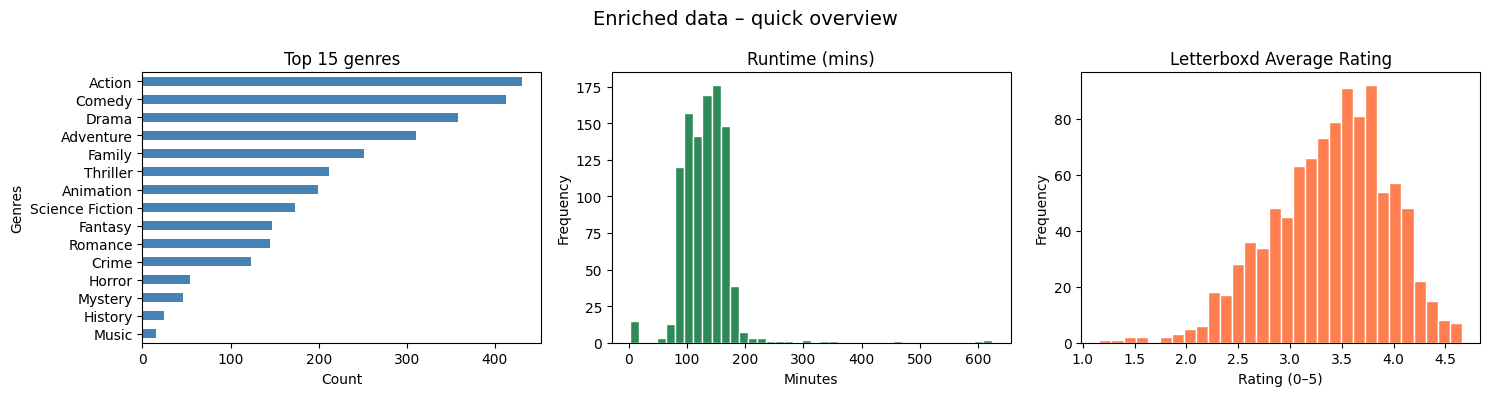

Saved enriched_overview.png


In [ ]:
# Quick visual sanity check of the enriched data
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Enriched data – quick overview", fontsize=14)

# 1. Top genres
genre_series = (
    df_final["Genres"]
    .dropna()
    .str.split("-")
    .explode()
    .str.strip()
)
genre_series.value_counts().head(15).plot.barh(ax=axes[0], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("Top 15 genres")
axes[0].set_xlabel("Count")

# 2. Runtime distribution
df_final["Runtime"].dropna().plot.hist(ax=axes[1], bins=40, color="seagreen", edgecolor="white")
axes[1].set_title("Runtime (mins)")
axes[1].set_xlabel("Minutes")

# 3. Average rating distribution
df_final["Average Rating"].dropna().plot.hist(ax=axes[2], bins=30, color="coral", edgecolor="white")
axes[2].set_title("Letterboxd Average Rating")
axes[2].set_xlabel("Rating (0–5)")

plt.tight_layout()
plt.savefig("../images/enriched_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved enriched_overview.png")
